In [26]:
import numpy as np 
import pandas as pd

In [27]:
df = pd.read_csv(r"C:\Users\kmpri\Downloads\support_tickets_raw.csv")

In [28]:
df.head(5)

,ticket_id,created_at,first_response_minutes,resolved_at,resolution_hours,priority,sla_frt_limit_mins,sla_resolve_limit_days,category,channel,agent,team,escalated,escalation_type,escalation_tier,reopened
0,TKT-0200,01-27-2024 13:14:00,32.5,30/01/2024 08:44,67.5,high,40,3,Technical,Email,Agent_Kumar,T1,No,NaN,NaN,No
1,TKT-0462,23/08/2024 13:05,77.7,08-24-2024 21:41:00,32.6,medium,40,3,Account,Phone,Agent_Ali,T2,No,NaN,NaN,No
2,TKT-0356,26/11/2024 08:19,28.6,11-30-2024 20:01:00,107.7,medium,40,3,Billing,Portal,Agent_Patel,T1,Yes,Customer Requested,T2>T3,No
3,TKT-0034,10-26-2024 14:57:00,8.8,NaN,NaN,critical,15,1,Account,Email,Agent_Ali,T2,No,NaN,NaN,Yes
4,TKT-0475,17/11/2024 13:09,NaN,2024-11-19 17:45:00,52.6,medium,40,3,Billing,Email,Agent_Ali,T1,No,NaN,NaN,No


 <!--  Your task — write this exploration script yourself:
Open your code editor and write a Python script that answers:

Shape — how many rows and columns?
Duplicates — how many duplicate ticket_id values?
Nulls — which columns have missing values and how many?
Date formats — print first 10 values of created_at
Data types — what dtype is each column? -->

In [29]:
df.shape

(520, 16)

In [30]:
df.duplicated().sum()

np.int64(20)

In [31]:
df.isnull().sum()

ticket_id                   0
created_at                  0
first_response_minutes     67
resolved_at                52
resolution_hours           52
priority                    0
sla_frt_limit_mins          0
sla_resolve_limit_days      0
category                    0
channel                     0
agent                       0
team                        0
escalated                   0
escalation_type           406
escalation_tier           406
reopened                    0
dtype: int64

In [32]:
df.describe()

,first_response_minutes,resolution_hours,sla_frt_limit_mins,sla_resolve_limit_days
count,453.000000,468.000000,520.000000,520.000000
mean,34.937528,65.863462,38.788462,4.003846
std,25.596629,52.855143,8.650429,2.081200
min,5.200000,1.100000,15.000000,1.000000
25%,15.600000,23.050000,40.000000,3.000000
50%,27.300000,53.200000,40.000000,3.000000
75%,43.900000,95.925000,45.000000,7.000000
max,104.200000,214.800000,45.000000,7.000000


In [33]:
df=df.drop_duplicates()

In [34]:
print(df.shape)
print(df.duplicated().sum())

(500, 16)
0


In [35]:
df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce", format='mixed')
df["resolved_at"] = pd.to_datetime(df["resolved_at"], errors="coerce", format='mixed')

In [36]:
print(df.dtypes)

ticket_id                         object
created_at                datetime64[ns]
first_response_minutes           float64
resolved_at               datetime64[ns]
resolution_hours                 float64
priority                          object
sla_frt_limit_mins                 int64
sla_resolve_limit_days             int64
category                          object
channel                           object
agent                             object
team                              object
escalated                         object
escalation_type                   object
escalation_tier                   object
reopened                          object
dtype: object


In [37]:
df.head(5)

,ticket_id,created_at,first_response_minutes,resolved_at,resolution_hours,priority,sla_frt_limit_mins,sla_resolve_limit_days,category,channel,agent,team,escalated,escalation_type,escalation_tier,reopened
0,TKT-0200,2024-01-27 13:14:00,32.5,2024-01-30 08:44:00,67.5,high,40,3,Technical,Email,Agent_Kumar,T1,No,NaN,NaN,No
1,TKT-0462,2024-08-23 13:05:00,77.7,2024-08-24 21:41:00,32.6,medium,40,3,Account,Phone,Agent_Ali,T2,No,NaN,NaN,No
2,TKT-0356,2024-11-26 08:19:00,28.6,2024-11-30 20:01:00,107.7,medium,40,3,Billing,Portal,Agent_Patel,T1,Yes,Customer Requested,T2>T3,No
3,TKT-0034,2024-10-26 14:57:00,8.8,NaT,NaN,critical,15,1,Account,Email,Agent_Ali,T2,No,NaN,NaN,Yes
4,TKT-0475,2024-11-17 13:09:00,NaN,2024-11-19 17:45:00,52.6,medium,40,3,Billing,Email,Agent_Ali,T1,No,NaN,NaN,No


In [38]:
df['first_response_minutes'] = df['first_response_minutes'].fillna('Not Logged')

In [39]:
df['first_response_minutes'] = pd.to_numeric(df['first_response_minutes'], errors='coerce')
df['frt_breach'] = np.where(df['first_response_minutes'] > df['sla_frt_limit_mins'], 'Yes', 'No')

print(df['frt_breach'].value_counts())

frt_breach
No     386
Yes    114
Name: count, dtype: int64


In [40]:
df['resolve_breach'] = np.where(df['resolution_hours'] > (df['sla_resolve_limit_days'] * 24), 'Yes', 'No')
df['sla_breach'] = np.where((df['frt_breach'] == 'Yes') | (df['resolve_breach'] == 'Yes'), 'Yes', 'No')

print(df['resolve_breach'].value_counts())
print(df['sla_breach'].value_counts())

resolve_breach
No     400
Yes    100
Name: count, dtype: int64
sla_breach
No     310
Yes    190
Name: count, dtype: int64


In [41]:
# aggregations
daily = df.groupby(df['created_at'].dt.date).agg(
    total_tickets=('ticket_id', 'count'),
    avg_frt=('first_response_minutes', 'mean'),
    avg_resolution=('resolution_hours', 'mean'),
    sla_breaches=('sla_breach', lambda x: (x == 'Yes').sum()),
    escalations=('escalated', lambda x: (x == 'Yes').sum()),
    reopened=('reopened', lambda x: (x == 'Yes').sum())
).reset_index()

weekly = df.groupby(df['created_at'].dt.isocalendar().week).agg(
    total_tickets=('ticket_id', 'count'),
    avg_frt=('first_response_minutes', 'mean'),
    avg_resolution=('resolution_hours', 'mean'),
    sla_breaches=('sla_breach', lambda x: (x == 'Yes').sum()),
    escalations=('escalated', lambda x: (x == 'Yes').sum()),
    reopened=('reopened', lambda x: (x == 'Yes').sum())
).reset_index()

print(daily.head())
print(weekly.head())

   created_at  total_tickets  avg_frt  avg_resolution  sla_breaches  \
0  2024-01-02              2    35.00           15.05             0   
1  2024-01-05              1    75.60          170.90             1   
2  2024-01-06              1    68.90          180.30             1   
3  2024-01-08              3    20.45           36.75             0   
4  2024-01-11              2    33.30           59.85             1   

   escalations  reopened  
0            0         0  
1            0         0  
2            0         0  
3            1         1  
4            0         0  
   week  total_tickets    avg_frt  avg_resolution  sla_breaches  escalations  \
0     1              4  59.833333       95.325000             2            0   
1     2              6  24.680000       48.840000             1            1   
2     3              6  43.300000       44.620000             2            1   
3     4             12  27.158333       82.890000             4            1   
4     5    

In [42]:
with pd.ExcelWriter('kpi_report.xlsx', engine='openpyxl') as writer:
    df.to_excel(writer, sheet_name='Raw_Data', index=False)
    daily.to_excel(writer, sheet_name='Daily_KPIs', index=False)
    weekly.to_excel(writer, sheet_name='Weekly_KPIs', index=False)

print("Excel exported successfully!")

Excel exported successfully!


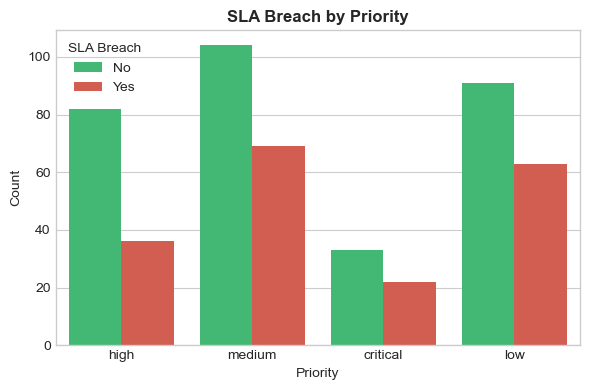

In [46]:
# SLA Breach Count
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='priority', hue='sla_breach', palette=['#2ecc71','#e74c3c'])
plt.title('SLA Breach by Priority', fontweight='bold')
plt.xlabel('Priority')
plt.ylabel('Count')
plt.legend(title='SLA Breach')
plt.tight_layout()
plt.savefig('chart1.png', dpi=150)
plt.show()

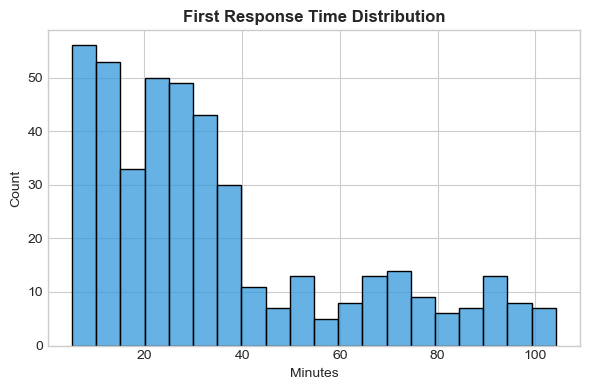

In [47]:
#  FRT Distribution
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='first_response_minutes', bins=20, color='#3498db')
plt.title('First Response Time Distribution', fontweight='bold')
plt.xlabel('Minutes')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('chart2.png', dpi=150)
plt.show()

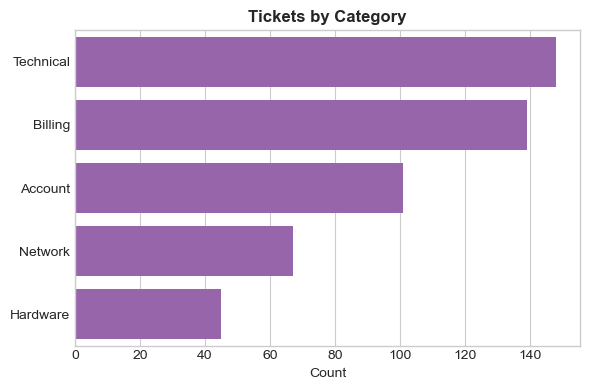

In [48]:
# Tickets by Category
plt.figure(figsize=(6,4))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index, color='#9b59b6')
plt.title('Tickets by Category', fontweight='bold')
plt.xlabel('Count')
plt.ylabel('')
plt.tight_layout()
plt.savefig('chart3.png', dpi=150)
plt.show()

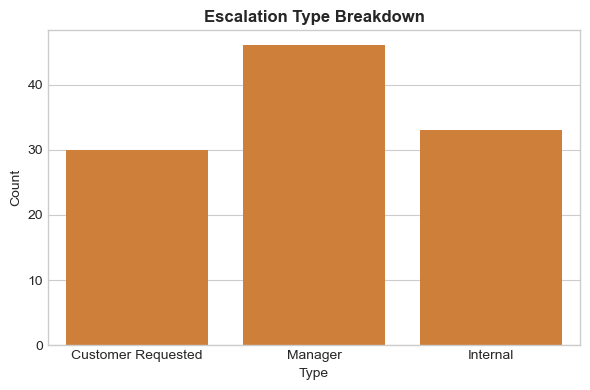

In [49]:
# Escalation Type
plt.figure(figsize=(6,4))
sns.countplot(data=df[df['escalated']=='Yes'], x='escalation_type', color='#e67e22')
plt.title('Escalation Type Breakdown', fontweight='bold')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('chart4.png', dpi=150)
plt.show()